## Описание набора данных
В данном проекте используется датасет, содержащий информацию о парфюмерных ароматах, собранный с сайта Randewoo. С помощью этих данных планируется провести анализ и сегментацию парфюмов по различным характеристикам.

Цель проекта: Построить модель машинного обучения, которая позволит разделить ароматы на кластеры на основе их числовых характеристик. Это поможет выявить рыночные ниши и сегментировать ассортимент

Признак  | Описание
-------------------|--------------------
Name       | название парфюма
Price       | цена за парфюм
Rating       | рейтинг (средняя оценка парфюма)
Review       | количество отзывов
Year        | год производства парфюма


*примечание:* в датасете присутствуют и другие колонки с категориальными данными, но они отсекаются сразу после загрузки датасета, так как не используются в анализе, так что представлено описание только используемых данных

## Описание набора данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("perfume_data_r.csv")
data = data[['Name', 'Price', 'Rating', 'Review', 'Year']]
print(data.head())
print("\nИнформация о данных\n")
print(data.info())
print("\nОписательная статистика\n")
print(data.describe())

                 Name     Price  Rating  Review    Year
0  Good Girl Gone Bad  109263.0     5.0  5568.0  2012.0
1         Lost Cherry   37273.0     5.0  5650.0  2018.0
2             Shadow     7260.0     5.0   580.0  2024.0
3  Baccarat Rouge 540   38962.0     5.0  4568.0  2015.0
4               Kirke   12028.0     5.0  5050.0  2015.0

Информация о данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15911 entries, 0 to 15910
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    15910 non-null  object 
 1   Price   13573 non-null  float64
 2   Rating  10781 non-null  float64
 3   Review  10781 non-null  float64
 4   Year    15007 non-null  float64
dtypes: float64(4), object(1)
memory usage: 621.6+ KB
None

Описательная статистика

               Price        Rating        Review          Year
count   13573.000000  10781.000000  10781.000000  15007.000000
mean    18094.580859      4.890455    117.986643   2014.162991
s

In [2]:
df = data
print("Размерность данных до очистки:", df.shape)

Размерность данных до очистки: (15911, 5)


## Предварительная обработка
#### Заполнение пропусков

In [3]:
print("Пропуски до очистки:")
print(df.isnull().sum())

df['Name'] = df['Name'].fillna('Unknown')

year_median = df['Year'].median()
df['Year'] = df['Year'].fillna(year_median)
print(f"Медиана года: {year_median}")
print(f"Диапазон годов: {df['Year'].min()} - {df['Year'].max()}")

price_median = df['Price'].median()
df['Price'] = df['Price'].fillna(price_median)
print(f"Медиана цены: {price_median}")
print(f"Диапазон цен: {df['Price'].min()} - {df['Price'].max()}")

df['Rating'] = df['Rating'].fillna(0)
df['Review'] = df['Review'].fillna(0)

print(f"\nПропуски после очистки:")
print(df.isnull().sum())

Пропуски до очистки:
Name         1
Price     2338
Rating    5130
Review    5130
Year       904
dtype: int64
Медиана года: 2017.0
Диапазон годов: 1786.0 - 2025.0
Медиана цены: 13952.0
Диапазон цен: 98.0 - 669130.0

Пропуски после очистки:
Name      0
Price     0
Rating    0
Review    0
Year      0
dtype: int64


#### Построение боксплотов и очистка от выбросов

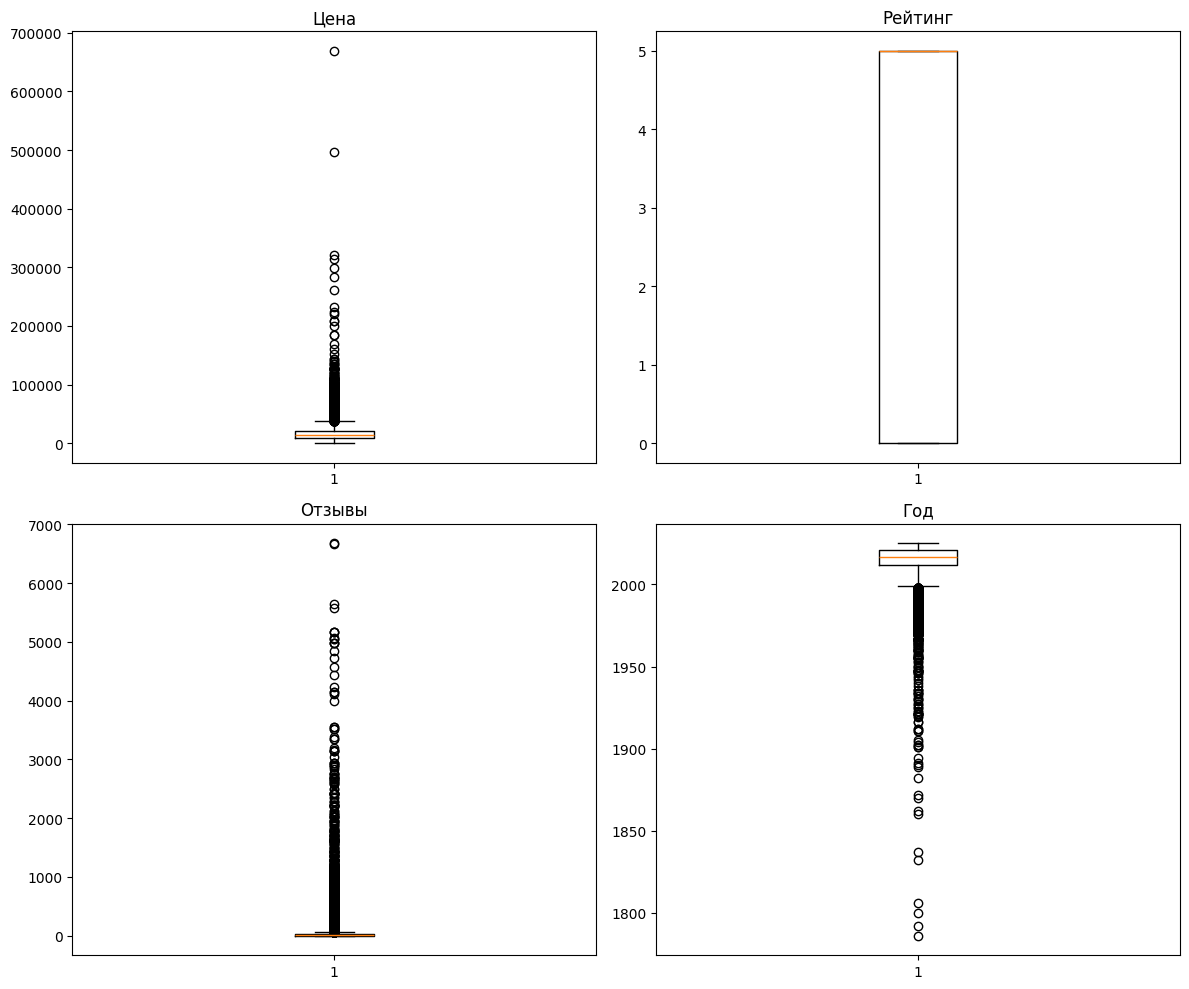


Размерность данных после очистки: (6968, 5)


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].boxplot(df['Price'])
axes[0, 0].set_title('Цена')

axes[0, 1].boxplot(df['Rating'])
axes[0, 1].set_title('Рейтинг')

axes[1, 0].boxplot(df['Review'])
axes[1, 0].set_title('Отзывы')

axes[1, 1].boxplot(df['Year'])
axes[1, 1].set_title('Год')

plt.tight_layout()
plt.show()

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
df = df[(df['Price'] <= upper_bound) & (df['Price'] >= lower_bound)]

Q1_rev = df['Review'].quantile(0.25)
Q3_rev = df['Review'].quantile(0.75)
IQR_rev = Q3_rev - Q1_rev
upper_bound_rev = Q3_rev + 1.5 * IQR_rev
lower_bound_rev = Q1_rev - 1.5 * IQR_rev
df = df[(df['Review'] <= upper_bound_rev) & (df['Review'] >= lower_bound_rev)]

Q1_year = df['Year'].quantile(0.25)
Q3_year = df['Year'].quantile(0.75)
IQR_year = Q3_year - Q1_year
upper_bound_year = Q3_year + 1.5 * IQR_year
lower_bound_year = Q1_year - 1.5 * IQR_year
df = df[(df['Year'] <= upper_bound_year) & (df['Year'] >= lower_bound_year)]


df = df[df['Rating'] >= 1]

print(f"\nРазмерность данных после очистки: {df.shape}")

Так как построенные боксплоты показывают большое количество выбросов была проведена очистка данных от них, а для рейтинга установлено минимальное значение 1, так как значения ниже означают отсутствие рейтинга

### Стандартизация данных
Так как данные имеют разную размерность и разброс было проведено преобразование данных для стандартизации, чтобы более эффективно провести поиск количества кластеров

In [5]:
cols = ['Price', 'Rating', 'Review', 'Year']
X = df.drop(['Name'], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Постановка задачи и построение модели
Задача выяснить можно ли ароматы разделить на кластера, в случае успеха проанализировать и интерпретировать полученные данные, отличительные особенности каждого кластера
Чтобы провести кластеризацию используем метод k-means, рассмотрим значения k от 2 до 15

### Метод локтя

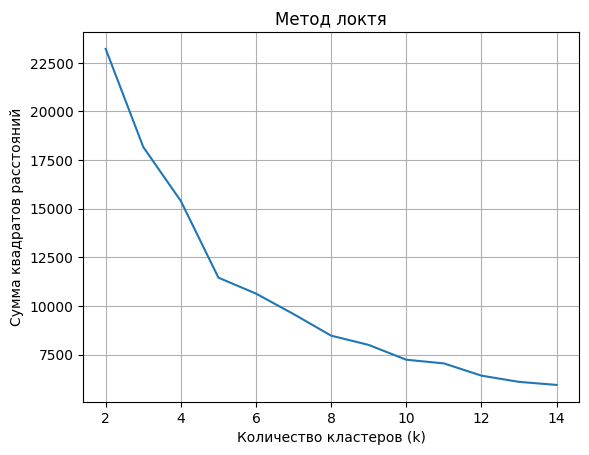

In [6]:
inertias = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Строим график
plt.figure()
plt.plot(K_range, inertias)
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов расстояний')
plt.title('Метод локтя')
plt.grid(True)
plt.show()

По графику видно, что сильное снижение суммы квадратов идет до k=5, далее снижение замедляется, так что было принято решение о том, чтобы разделить данные именно на 5 кластеров

Далее визуализируем полученные результаты с помощью метода главных компонент, так как у нас 4 признака и нужно уменьшить размерность до 2

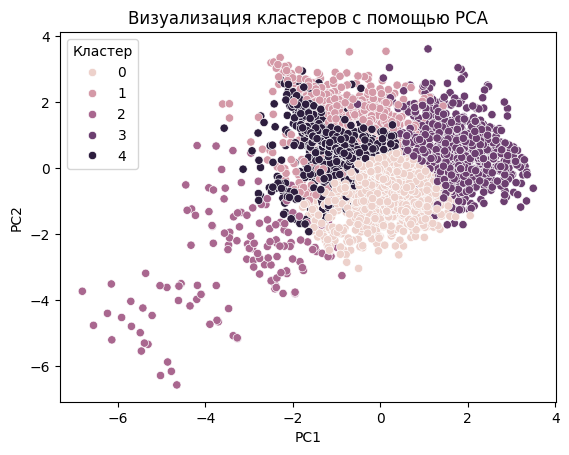

In [7]:
k = 5
kmeans = KMeans(n_clusters=k)
df['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
df['PC1'] = principal_components[:, 0]
df['PC2'] = principal_components[:, 1]

plt.figure()
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df)
plt.title(f'Визуализация кластеров с помощью PCA')
plt.legend(title='Кластер')
plt.show()

## Оценка модели и результатов

### Средние значения по кластерам

In [8]:
cluster_analysis = df.groupby('Cluster')[cols].mean()
print("Средние значения признаков по кластерам:")
print(cluster_analysis)


Средние значения признаков по кластерам:
                Price    Rating     Review         Year
Cluster                                                
0        10272.795072  4.911104   6.073612  2018.782907
1        25785.703074  4.900485   6.805016  2015.618932
2        13133.897959  2.826531   1.945578  2014.639456
3        13350.196375  4.950906  36.455186  2017.655589
4        12175.708514  4.914322   6.653680  2007.961039


## Интерпретация кластеров

#### Классические популярные ароматы
Показатель |  Значение
-------------------|--------------------
Цена | 13 350
Рейтинг | 4.95
Количество отзывов | 36.6
Год производства | 2018

Средний ценовой сегмент, большое количество отзывов, узнаваемые, высокий рейтинг, актуальные, рекомендуются для всех

#### Винтажные ароматы
Показатель |  Значение
-------------------|--------------------
Цена | 12 176
Рейтинг | 4.94
Количество отзывов | 6.8
Год производства | 2008

Средний ценовой сегмент, среднее количесвтво отзывов, очень высокие оценки, при этом очень ранний год производства, они намного старше других групп ароматов, рекомендуется для ценителей, коллекционеров и экспериментаторов

#### Бюджетные ароматы
Показатель |  Значение
-------------------|--------------------
Цена | 10 273
Рейтинг | 4.94
Количество отзывов | 6.2
Год производства | 2019

Самая дешевая линейка, также высокий рейтинг, уже меньше отзывов, чем у люкса, более молодые ароматы по году производства, рекомендуются для экономных людей, желающих найти свой аромат

#### Провальные и спорные ароматы
Показатель |  Значение
-------------------|--------------------
Цена | 13 134
Рейтинг | 3.44
Количество отзывов | 2.3
Год производства | 2015

Ароматы среднего и выше среднего ценового сегмента, при этом оценок мало, а имеющиеся очень низкие, ароматы не пользуются популярностью, не рекомендуется к покупке, высокий риск недовольства продуктом

#### Люксовые ароматы
Показатель |  Значение
-------------------|--------------------
Цена | 25 786
Рейтинг | 4.93
Количество отзывов | 7.0
Год производства | 2016

Самые дорогие из всех групп, с высоким рейтингом, также с большим количеством отзывов, меньше чем у классики, но тем не менее они популярны, рекомендуются для людей с более высоким доходом





## Вывод:

Модель позволила успешно сегментировать парфюмерные ароматы на 5 кластеров

Полученные данные можно использовать для:

-Анализа парфюмерного рынка

-Понимания текущих трендов

-Создания маркетинговых стратегий, таких как, например, персональные рекомендации для пользователей разных кластеров ароматов

-Формирования позиционирования бренда

-Понимания аудитории для того, чтобы спрогнозировать какой аромат будет иметь наибольшую популярность при добавлении в ассортимент

Была выполнена загрузка данных, очистка этих данных от выбросов и отсутствующих значений, далее данные преобразованы для использования в модели, и в конце были проанализированы полученные результаты, сформировано описание полученных кластеров